In [50]:
import pandas as pd
from scipy.io import wavfile
from egg_io import *
from fpca_preprocess import *
import matplotlib.pyplot as plt

all_data = pd.read_csv("voiceSauce.csv")
TIMEPOINT = 4

In [51]:
savedRow = random_test_file(all_data, filterLanguage = 'Hmong')
# savedRow = grabSpecificFile(all_data, 'egg_melt/Zapotec/speaker1M_eM3.wav')
# savedRow = grabSpecificFile(all_data, 'egg_melt/Bo/Village 2/F3_srii33_01.wav')
# savedRow = grabSpecificFile(all_data, 'egg_melt/Bo/Village 2/F3_thuu_33_01.wav')
# savedRow = grabSpecificFile(all_data, 'egg_melt/Bo/Village 1/F1_dze_33_02 .wav')

savedRow

Found file after 553 attempts.


speaker_id            Hmong_M14
speaker_number               14
speaker_sex                   M
language                  Hmong
language_variety    White Hmong
                       ...     
SQ2_SQ1                   0.833
SQ4_SQ3                   3.739
ratio                     0.223
LPhon               Hmong-Modal
SQ                     0.222787
Name: 2184, Length: 80, dtype: object

In [52]:
# samplerate, data = wavfile.read(filepath(savedRow))
# startSample, endSample = sampleEndpoints(savedRow.segment_start, savedRow.segment_end, samplerate, timepoint = TIMEPOINT)
# egg = data[startSample:endSample]

egg, samplerate = loadFile(savedRow, TIMEPOINT)

In [53]:
# new thing! low pass!
egg = lowpass(egg, samplerate, 722)

In [54]:
peaks = pitchmark(egg, samplerate, savedRow.strF0)
threshold = find_threshold(egg, peaks)

<function matplotlib.pyplot.show(close=None, block=None)>

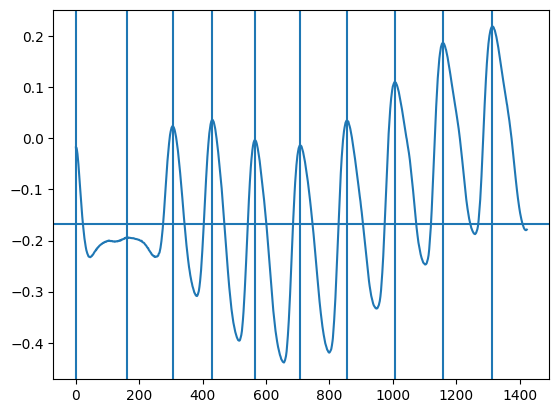

In [55]:
plt.plot(egg)
for peak in peaks:
    plt.axvline(peak)
plt.axhline(threshold)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

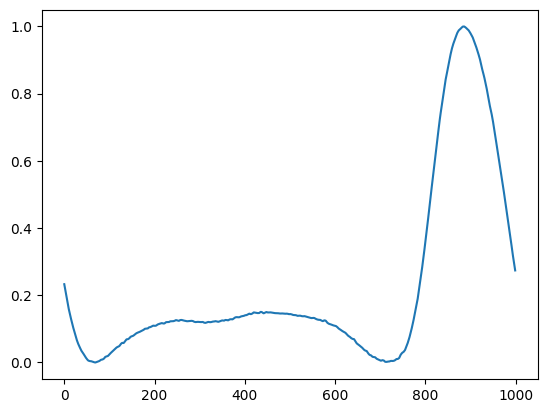

In [56]:
clipped_egg = clip_egg(egg, threshold, peaks)
# TODO: we're getting list index out of range here, in low-F0 cases. look into that if it happens a bunch!
# TODO: also, a lot of the gujarati data is reeeally choppy, i'd look into ways of making this algorithm more robust!
# ^ further, sometimes even in other languages the threshold is too low. raising it would come at the cost of research backing, but might give us more pages!!!
final = normalize_egg(clipped_egg)

plt.plot(final)
plt.show